In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
from skbio.diversity import beta_diversity
from skbio.diversity import alpha_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import anosim

/home/huayuqin/miniconda3/envs/soil/lib/python3.11/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [28]:
otu_tab = pd.read_csv('../pre-calculated_data/all_otu_table.S3.5.rib_prot_S2_rpsB.ebd', sep='\t', index_col=0)
otu_tab

,AAAAAAAACGCGAACCGCTACGCCCGCAAGGTCGGATTTACGTCGGTGGCGTTGATCGAC,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCATCAGCGAATCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCGTGAAAGAAGCCCGCAAGCTGGGCATCGCCACGGTGGCGCTCATCGAC,AAAAAGATAGCCAACAAAGAAGCGCACCGGCTCAAAAAAAACGTCGCGGCAATCGTCCAA,AAAAATATTGCATTGAAAGAAGCGCAGAGATTAAACGTAAACACTTTTGGAATTGTTGAT,AAAAATGGGGCGCTCGCGGAAGCGAAGCGACTCGGCATTCCGATCGTTGGCATCGTCGAT,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AAACACAACGCCGTTGCTGAGGCGCGTCGGCTCAAAATCCCGGTCGTCGCGATAGTGGAT,AAACACAACGCGGTGAAGGAAGCCCGCCGCCTGTCGATCCCGGTCATCGCCATGCTCGAC,...,TGCGCAGTTCGTATCGACGACTGCAACGACAGGAATACCGAGCTTCTTGGCTTCGTGAAT,TGGAGAATCTGTGTCACAGAGAGCAATAACGGGAATGTTGACGTAGCTGGCCTCCTTGAT,TGGCACCTGGCGGTCGAGGAGGCCCGCAAGCTGCGGATCCCGATCATCGGCATCCTCGAC,TGTGAAAATGTTTCAGATGAATTTGCTTCAGCTAACATTCCAACTATAGGAATTGTTGAC,TTCAGAGAAGTTGTATCTGAAGCTTATGATATGGAGATTCCAGTTGTTGCGGCAATGGAT,TTGAAGATCTCGATAATGGTTGGCCGGGCACTCCGCATAAAAACAGTCTCGATGATCGAC,TTGAATATCGCATTCACAGAAGCAATACGGCTGGGTATGGGTACTTTCGGGATGGTGGAG,TTGCGCATCGCGGTCAGCGAGGCGAACAAGCTGGGCATCCCGATCGTCGCTATGGTGGAC,TTTGCTGCAGCGATAAAAGAGGCTTCATCCTTGAGTATTCCATCGTTAGGATTGATGGAT,TTTTATTCGTGTTTTTTTGAATCGACTTATTGTGGAATTCCGGCTATTGGTATGATTGAT
CPSNJ01_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ11_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
metadata = pd.read_csv('../pre-calculated_data/metadata_otu.csv', index_col='Sample')
metadata.loc[metadata['Site'].str.startswith('NanJing'), 'Site'] = 'NanJing'
metadata.loc[metadata['Site'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
metadata

,Site
Sample,
CPSNJ01_350,NanJing
CPSNJ02_350,NanJing
CPSNJ03_350,NanJing
CPSNJ04_350,NanJing
CPSNJ08_350,NanJing
CPSNJ09_350,NanJing
CPSNJ10_350,NanJing
CPSNJ11_350,NanJing
CPSNJ13_350,NanJing


In [51]:
otus_rows = otu_tab.index.tolist()
adiv_obs_otus = alpha_diversity('observed_otus', otu_tab , otus_rows)
chao1 = alpha_diversity('chao1',otu_tab , otus_rows)
shannon = alpha_diversity('shannon', otu_tab , otus_rows)
simpson = alpha_diversity('simpson', otu_tab , otus_rows)
metadata['Observed OTUs'] = adiv_obs_otus
metadata['chao1'] = chao1
metadata['shannon'] = shannon
metadata['simpson'] = simpson
metadata

,Site,Observed OTUs,chao1,shannon,simpson
Sample,,,,,
CPSNJ01_350,NanJing,2445,4482.000000,10.893190,0.999247
CPSNJ02_350,NanJing,2616,5325.478947,11.131909,0.999457
CPSNJ03_350,NanJing,2202,4044.156057,10.761532,0.999198
CPSNJ04_350,NanJing,2464,4996.046512,10.984664,0.999339
CPSNJ08_350,NanJing,2899,5911.825641,11.106268,0.999287
CPSNJ09_350,NanJing,1825,3278.795567,10.445269,0.998940
CPSNJ10_350,NanJing,2471,4580.255396,10.923031,0.999256
CPSNJ11_350,NanJing,2106,3578.688797,10.624026,0.999056
CPSNJ13_350,NanJing,2029,3584.917722,10.606325,0.999051


In [33]:
metadata_dog= pd.read_csv('../pre-calculated_data/dog.csv',index_col=0)
metadata_dog

,Site
Original_sample_name,
D000_350,Dog
D001_350,Dog
D002_350,Dog
D003_350,Dog
D004_350,Dog
D005_350,Dog
D006_350,Dog
D007_350,Dog
D008_350,Dog


In [38]:
otu_tab_dog = pd.read_csv('../pre-calculated_data/dog_all-otu-table.S3.5.rib_prot_S2_rpsB.ebd', sep='\t', index_col=0)
otu_tab_dog

,AAAAAAAAAGCAGTACGGGAAGCAAACAGTGTTGGTATAAAATTATTCGCAATCGTTAAT,AAAAAAACCTGTGTCCAGAAAGCCACCCCTCTGGGAATTCCGCTAACCGGATCTTGTGAT,AAAAAAATCCGTTTTTCCGAAGCCCGGAAACTTCACCACCCCATCCCCGCCACGGTTGAC,AAAAAAATCGCTGTGGCGGAAGCTAGAAGGCTTGGGATTCCCGTTGTTGCACCGCTTGAT,AAAAAAATCGCTGTTCCCGGGGCTAACCGTTTGGGTATTCCTGTGTTCGGTATCGTTGAT,AAAAAAATTCCGGGGCGGAAAGCAATCCGTTTGGGAATTCCTGTTTTTGCAATCGTTAAA,AAAAAAATTGCAGTGCGTGAAGCTAATCGTTTGGGTATTCCTGTGTTTGCTATCGTTGAT,AAAAAAATTGCTATCCAGGAAGCTCACATCCTTGGCATTCCTGTAGTTGCAATTGTAGAT,AAAAAAATTGCTGTGGCGGAAGCTAGGAGGCTTGGGATTCCCGTTGTTGCACCGCTTGAT,AAAAAAATTGGTGTTGGGGAAGCTAAACGACGGGGTATCGCTGTAATAGCTATTGTGGTT,...,TTGCATATCGCAGTAGCGGAGGCCAACCGTCTGGGTATGCCCGTGTTTGCGATGGTCGAC,TTGCGCATTGCTGTGGCTGAGGCCCGCAAGCTGCATATCCCCATCGTGGCTATCGTTGAT,TTGCGCCTGGCTGTTGAGTTAGCTCACACTCTGGGTATCCCGTTTGTCTCCATCGTCGAC,TTGCGTATCGCTGTTAAGGAAGCACAAAAGCTTAACATTCCTATCGTTGCTATGGTCGAC,TTGGATAACGCATTCACGGAGGCTACGCGCCTCGGCATCCCGGTGGTCGCCCTCATCGAC,TTGGATACCGCAATCAAGGAGGCCACGCGCCTCGGCATCCCGGTGGTCGCCCTCATCGAC,TTTATATTCTGTGTACAGGAAGCTCATACATTAGGTATTCCGTTAATTGGTATCGCTGAT,TTTATCATTGCAGTACGCGAAGCTAACCGTCTTGGTATTCCTGTATTCGCAATCGTTGAT,TTTATTATGGGAGTTCGTGAAGCTAACCGTTTGGGTTTTCCAGTATTCGGTATCGTTGAT,TTTATTATTTGTCTCCATGAAGCTCATACATTCGTTATTCAGTTAATTTGTATCGCTTAT
D000_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D001_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D002_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D003_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D004_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR14842421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR14842420,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR14842419,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR14842418,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
otu_tab_dog = otu_tab_dog[otu_tab_dog.index.str.startswith('D')]
otu_tab_dog

,AAAAAAAAAGCAGTACGGGAAGCAAACAGTGTTGGTATAAAATTATTCGCAATCGTTAAT,AAAAAAACCTGTGTCCAGAAAGCCACCCCTCTGGGAATTCCGCTAACCGGATCTTGTGAT,AAAAAAATCCGTTTTTCCGAAGCCCGGAAACTTCACCACCCCATCCCCGCCACGGTTGAC,AAAAAAATCGCTGTGGCGGAAGCTAGAAGGCTTGGGATTCCCGTTGTTGCACCGCTTGAT,AAAAAAATCGCTGTTCCCGGGGCTAACCGTTTGGGTATTCCTGTGTTCGGTATCGTTGAT,AAAAAAATTCCGGGGCGGAAAGCAATCCGTTTGGGAATTCCTGTTTTTGCAATCGTTAAA,AAAAAAATTGCAGTGCGTGAAGCTAATCGTTTGGGTATTCCTGTGTTTGCTATCGTTGAT,AAAAAAATTGCTATCCAGGAAGCTCACATCCTTGGCATTCCTGTAGTTGCAATTGTAGAT,AAAAAAATTGCTGTGGCGGAAGCTAGGAGGCTTGGGATTCCCGTTGTTGCACCGCTTGAT,AAAAAAATTGGTGTTGGGGAAGCTAAACGACGGGGTATCGCTGTAATAGCTATTGTGGTT,...,TTGCATATCGCAGTAGCGGAGGCCAACCGTCTGGGTATGCCCGTGTTTGCGATGGTCGAC,TTGCGCATTGCTGTGGCTGAGGCCCGCAAGCTGCATATCCCCATCGTGGCTATCGTTGAT,TTGCGCCTGGCTGTTGAGTTAGCTCACACTCTGGGTATCCCGTTTGTCTCCATCGTCGAC,TTGCGTATCGCTGTTAAGGAAGCACAAAAGCTTAACATTCCTATCGTTGCTATGGTCGAC,TTGGATAACGCATTCACGGAGGCTACGCGCCTCGGCATCCCGGTGGTCGCCCTCATCGAC,TTGGATACCGCAATCAAGGAGGCCACGCGCCTCGGCATCCCGGTGGTCGCCCTCATCGAC,TTTATATTCTGTGTACAGGAAGCTCATACATTAGGTATTCCGTTAATTGGTATCGCTGAT,TTTATCATTGCAGTACGCGAAGCTAACCGTCTTGGTATTCCTGTATTCGCAATCGTTGAT,TTTATTATGGGAGTTCGTGAAGCTAACCGTTTGGGTTTTCCAGTATTCGGTATCGTTGAT,TTTATTATTTGTCTCCATGAAGCTCATACATTCGTTATTCAGTTAATTTGTATCGCTTAT
D000_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D001_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D002_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D003_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D004_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D005_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D006_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D007_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D008_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D010_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [45]:
otus_rows_dog = otu_tab_dog.index.tolist()
adiv_obs_otus_dog = alpha_diversity('observed_otus', otu_tab_dog , otus_rows_dog)
chao1_dog = alpha_diversity('chao1',otu_tab_dog , otus_rows_dog)
shannon_dog = alpha_diversity('shannon', otu_tab_dog , otus_rows_dog)
simpson_dog = alpha_diversity('simpson', otu_tab_dog , otus_rows_dog)
metadata_dog['Observed OTUs'] = adiv_obs_otus_dog
metadata_dog['chao1'] = chao1
metadata_dog['shannon'] = shannon
metadata_dog['simpson'] = simpson
metadata_dog

,Site,Observed OTUs,chao1,shannon,simpson
Original_sample_name,,,,,
D000_350,Dog,424,1686.441860,4.401629,0.869331
D001_350,Dog,383,1226.125000,4.615401,0.902234
D002_350,Dog,238,763.777778,2.794766,0.636370
D003_350,Dog,565,3333.916667,5.436924,0.930319
D004_350,Dog,459,2546.343750,5.581598,0.948824
D005_350,Dog,575,2830.217391,5.510618,0.943939
D006_350,Dog,286,1848.647059,4.625316,0.918799
D007_350,Dog,429,2074.441176,4.401582,0.878831
D008_350,Dog,518,2162.300000,4.507081,0.859258


In [52]:
result = pd.concat([metadata, metadata_dog], axis=0)
result.to_csv('/mnt/c/Users/admin/soil_analysis/pre-calculated_data/alpha_diversity.csv')
result

,Site,Observed OTUs,chao1,shannon,simpson
CPSNJ01_350,NanJing,2445,4482.000000,10.893190,0.999247
CPSNJ02_350,NanJing,2616,5325.478947,11.131909,0.999457
CPSNJ03_350,NanJing,2202,4044.156057,10.761532,0.999198
CPSNJ04_350,NanJing,2464,4996.046512,10.984664,0.999339
CPSNJ08_350,NanJing,2899,5911.825641,11.106268,0.999287
...,...,...,...,...,...
D048_350,Dog,235,1150.055556,3.812373,0.870817
D049_350,Dog,270,1010.454545,4.404463,0.868107
D050_350,Dog,352,1644.700000,3.508157,0.790104
D051_350,Dog,237,1132.789474,4.309769,0.907449


In [9]:
df = pd.read_csv('../pre-calculated_data/alpha_diversity.csv')
df

,Unnamed: 0,Site,Observed OTUs,chao1,shannon,simpson
0,CPSNJ01_350,NanJing,2445,4482.000000,10.893190,0.999247
1,CPSNJ02_350,NanJing,2616,5325.478947,11.131909,0.999457
2,CPSNJ03_350,NanJing,2202,4044.156057,10.761532,0.999198
3,CPSNJ04_350,NanJing,2464,4996.046512,10.984664,0.999339
4,CPSNJ08_350,NanJing,2899,5911.825641,11.106268,0.999287
...,...,...,...,...,...,...
105,D048_350,Dog,235,1150.055556,3.812373,0.870817
106,D049_350,Dog,270,1010.454545,4.404463,0.868107
107,D050_350,Dog,352,1644.700000,3.508157,0.790104
108,D051_350,Dog,237,1132.789474,4.309769,0.907449


<ipython-input-3-daaf2fb7ac39>:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


Text(0.5, 24.0, '')

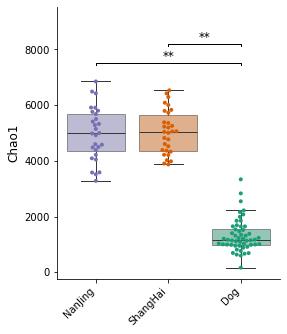

In [3]:
custom_palette = {
    'NanJing': '#7570b3',
    'ShangHai': '#d95f02',
    'Dog': '#1b9e77'
}

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df, x="Site", y="chao1", color='white', hue="Site", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax)

sns.swarmplot(data=df, x="Site", y="chao1", hue="Site", 
             palette=custom_palette, ax=ax,size=4)

tukey = pairwise_tukeyhsd(endog=df['chao1'], groups=df['Site'], alpha=0.05)
summary = tukey.summary()

significant_pairs = []
for i in range(1, len(summary.data)):
    row = summary.data[i]
    if float(row[3]) < 0.05:
        group1 = row[0]
        group2 = row[1]
        p_val = float(row[3])
        significant_pairs.append( (group1, group2, p_val) )

group_order = df['Site'].unique()
x_positions = {group: idx for idx, group in enumerate(group_order)}

y_max = df['chao1'].max()
y_min = df['chao1'].min()
vertical_offset = 0.1 * (y_max - y_min)
current_level = 1  
line_props = {'color': 'black', 'linewidth': 1, 'transform': ax.transData}
for pair in significant_pairs:
    group1, group2, p_val = pair
    x1 = x_positions[group1]
    x2 = x_positions[group2]
    if p_val < 0.001:
        symbol = '***'
    elif p_val < 0.01:
        symbol = '**'
    elif p_val < 0.05:
        symbol = '*'
    else:
        continue
    y_top = y_max + (vertical_offset * current_level)
    y_line = y_top - 0.1 * vertical_offset
    ax.plot([x1, x1, x2, x2], 
            [y_line, y_top, y_top, y_line], **line_props)
    ax.text((x1+x2)/2, y_top, symbol, 
            ha='center', va='bottom', 
            fontsize=12, color='black')
    current_level += 1 

ax.set_ylim(top=y_max + vertical_offset * (current_level + 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Chao1', fontsize=12)
ax.set_xlabel('')

<ipython-input-24-af1e0d76b94a>:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


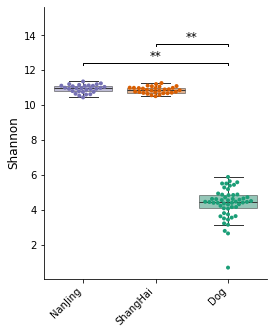

In [24]:
custom_palette = {
    'NanJing': '#7570b3',
    'ShangHai': '#d95f02',
    'Dog': '#1b9e77'
}

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df, x="Site", y="shannon", color='white', hue="Site", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax)

sns.swarmplot(data=df, x="Site", y="shannon", hue="Site", 
             palette=custom_palette, ax=ax,size=4)

tukey = pairwise_tukeyhsd(endog=df['shannon'], groups=df['Site'], alpha=0.05)
summary = tukey.summary()

significant_pairs = []
for i in range(1, len(summary.data)):
    row = summary.data[i]
    if float(row[3]) < 0.05:
        group1 = row[0]
        group2 = row[1]
        p_val = float(row[3])
        significant_pairs.append( (group1, group2, p_val) )

group_order = df['Site'].unique()
x_positions = {group: idx for idx, group in enumerate(group_order)}

y_max = df['shannon'].max()
y_min = df['shannon'].min()
vertical_offset = 0.1 * (y_max - y_min)
current_level = 1  
line_props = {'color': 'black', 'linewidth': 1, 'transform': ax.transData}
for pair in significant_pairs:
    group1, group2, p_val = pair
    x1 = x_positions[group1]
    x2 = x_positions[group2]
    if p_val < 0.001:
        symbol = '***'
    elif p_val < 0.01:
        symbol = '**'
    elif p_val < 0.05:
        symbol = '*'
    else:
        continue
    y_top = y_max + (vertical_offset * current_level)
    y_line = y_top - 0.1 * vertical_offset
    ax.plot([x1, x1, x2, x2], 
            [y_line, y_top, y_top, y_line], **line_props)
    ax.text((x1+x2)/2, y_top, symbol, 
            ha='center', va='bottom', 
            fontsize=12, color='black')
    current_level += 1 

ax.set_ylim(top=y_max + vertical_offset * (current_level + 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Shannon', fontsize=12)
ax.set_xlabel('')

In [10]:
df['-log(simpson)'] = -np.log(df['simpson'])
df

,Unnamed: 0,Site,Observed OTUs,chao1,shannon,simpson,-log(simpson)
0,CPSNJ01_350,NanJing,2445,4482.000000,10.893190,0.999247,0.000753
1,CPSNJ02_350,NanJing,2616,5325.478947,11.131909,0.999457,0.000543
2,CPSNJ03_350,NanJing,2202,4044.156057,10.761532,0.999198,0.000802
3,CPSNJ04_350,NanJing,2464,4996.046512,10.984664,0.999339,0.000661
4,CPSNJ08_350,NanJing,2899,5911.825641,11.106268,0.999287,0.000713
...,...,...,...,...,...,...,...
105,D048_350,Dog,235,1150.055556,3.812373,0.870817,0.138323
106,D049_350,Dog,270,1010.454545,4.404463,0.868107,0.141440
107,D050_350,Dog,352,1644.700000,3.508157,0.790104,0.235590
108,D051_350,Dog,237,1132.789474,4.309769,0.907449,0.097118


C:\Users\admin\anaconda3\lib\site-packages\seaborn\categorical.py:3370: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
<ipython-input-28-c58618da27a5>:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


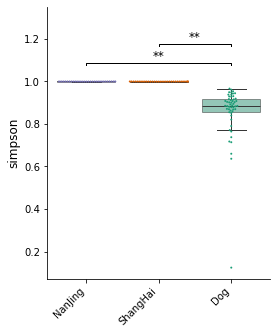

In [28]:
custom_palette = {
    'NanJing': '#7570b3',
    'ShangHai': '#d95f02',
    'Dog': '#1b9e77'
}

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df, x="Site", y='simpson', color='white', hue="Site", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax)

sns.swarmplot(data=df, x="Site", y='simpson', hue="Site", 
             palette=custom_palette, ax=ax,size=2)
tukey = pairwise_tukeyhsd(endog=df['simpson'], groups=df['Site'], alpha=0.05)
summary = tukey.summary()

significant_pairs = []
for i in range(1, len(summary.data)):
    row = summary.data[i]
    if float(row[3]) < 0.05:
        group1 = row[0]
        group2 = row[1]
        p_val = float(row[3])
        significant_pairs.append( (group1, group2, p_val) )

group_order = df['Site'].unique()
x_positions = {group: idx for idx, group in enumerate(group_order)}

y_max = df['simpson'].max()
y_min = df['simpson'].min()
vertical_offset = 0.1 * (y_max - y_min)
current_level = 1  
line_props = {'color': 'black', 'linewidth': 1, 'transform': ax.transData}
for pair in significant_pairs:
    group1, group2, p_val = pair
    x1 = x_positions[group1]
    x2 = x_positions[group2]
    if p_val < 0.001:
        symbol = '***'
    elif p_val < 0.01:
        symbol = '**'
    elif p_val < 0.05:
        symbol = '*'
    else:
        continue
    y_top = y_max + (vertical_offset * current_level)
    y_line = y_top - 0.1 * vertical_offset
    ax.plot([x1, x1, x2, x2], 
            [y_line, y_top, y_top, y_line], **line_props)
    ax.text((x1+x2)/2, y_top, symbol, 
            ha='center', va='bottom', 
            fontsize=12, color='black')
    current_level += 1 

ax.set_ylim(top=y_max + vertical_offset * (current_level + 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('simpson', fontsize=12)
ax.set_xlabel('')
plt.savefig(r'D:\soil\manuscript\draft\mine\simpson.svg')

In [3]:
otu_tab = pd.read_csv('../pre-calculated_data/all_otu_table.S3.5.rib_prot_S2_rpsB.ebd', sep='\t', index_col=0)
otu_tab

,AAAAAAAACGCGAACCGCTACGCCCGCAAGGTCGGATTTACGTCGGTGGCGTTGATCGAC,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCATCAGCGAATCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCGTGAAAGAAGCCCGCAAGCTGGGCATCGCCACGGTGGCGCTCATCGAC,AAAAAGATAGCCAACAAAGAAGCGCACCGGCTCAAAAAAAACGTCGCGGCAATCGTCCAA,AAAAATATTGCATTGAAAGAAGCGCAGAGATTAAACGTAAACACTTTTGGAATTGTTGAT,AAAAATGGGGCGCTCGCGGAAGCGAAGCGACTCGGCATTCCGATCGTTGGCATCGTCGAT,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AAACACAACGCCGTTGCTGAGGCGCGTCGGCTCAAAATCCCGGTCGTCGCGATAGTGGAT,AAACACAACGCGGTGAAGGAAGCCCGCCGCCTGTCGATCCCGGTCATCGCCATGCTCGAC,...,TGCGCAGTTCGTATCGACGACTGCAACGACAGGAATACCGAGCTTCTTGGCTTCGTGAAT,TGGAGAATCTGTGTCACAGAGAGCAATAACGGGAATGTTGACGTAGCTGGCCTCCTTGAT,TGGCACCTGGCGGTCGAGGAGGCCCGCAAGCTGCGGATCCCGATCATCGGCATCCTCGAC,TGTGAAAATGTTTCAGATGAATTTGCTTCAGCTAACATTCCAACTATAGGAATTGTTGAC,TTCAGAGAAGTTGTATCTGAAGCTTATGATATGGAGATTCCAGTTGTTGCGGCAATGGAT,TTGAAGATCTCGATAATGGTTGGCCGGGCACTCCGCATAAAAACAGTCTCGATGATCGAC,TTGAATATCGCATTCACAGAAGCAATACGGCTGGGTATGGGTACTTTCGGGATGGTGGAG,TTGCGCATCGCGGTCAGCGAGGCGAACAAGCTGGGCATCCCGATCGTCGCTATGGTGGAC,TTTGCTGCAGCGATAAAAGAGGCTTCATCCTTGAGTATTCCATCGTTAGGATTGATGGAT,TTTTATTCGTGTTTTTTTGAATCGACTTATTGTGGAATTCCGGCTATTGGTATGATTGAT
CPSNJ01_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ11_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
#remove samples (<100 total count OTUs)
otus_filt = otu_tab[otu_tab.sum(axis=1) >= 100]
otus_filt_wo0 = otus_filt[otus_filt.sum(axis=1) > 0]
otus_filt_wo0 = otus_filt_wo0.loc[:,otus_filt_wo0.sum(axis=0) > 0]

otus_filt_wo0['Sum'] = otus_filt_wo0.sum(axis=1)
otus_RA = otus_filt_wo0.iloc[:, :].div(otus_filt_wo0.Sum, axis=0)
otus_RA = otus_RA.drop(['Sum'], axis=1)

#remove low RA
otus_RA = otus_RA.T
otus_RA['Mean'] = otus_RA.mean(axis=1)
otus_RA_filt = otus_RA.loc[otus_RA['Mean'].between(0.00001, 1)]
otus_RA_filt = otus_RA_filt.drop(['Mean'], axis=1)
otus_RA_filt 

,CPSNJ01_350,CPSNJ02_350,CPSNJ03_350,CPSNJ04_350,CPSNJ08_350,CPSNJ09_350,CPSNJ10_350,CPSNJ11_350,CPSNJ13_350,CPSNJ14_350,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000809,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000258,0.0,0.0,0.000782,0.0,0.0,0.0,0.0,0.0,0.00019


In [5]:
otus_RA_filt_zoom = otus_RA_filt * 1000000
np.set_printoptions(precision=5)
otus_np = otus_RA_filt_zoom.to_numpy()

minval = np.min(otus_np[np.nonzero(otus_np)])
pseudo = minval/2
otus_RA_filt_zoom.replace([0],pseudo, inplace=True)

otus_RA_filt_zoom = otus_RA_filt_zoom.T
otus_RA_filt_zoom

,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,AATTATATAATATGTAATGAGGCTATATCTATGTTTTTGCCTATTATTGCAATAGTTGAC,AATTATATAGTTTTAAAAGAAGCCGCTTTAATGTTTATGCCTGTTATAGGTATTATTGAT,ACACATCCAGCAGTCGTCGATTCGGCTAAACTCCTGATCCCGACCGTCGGTATTGTTGAC,AGAACAATTTGTGTCGACGACTGCAACGATGGGGATGCCCAGACGATTAGCTTCAGCGAC,AGCGCCAACGCCGTGCGCGAAGCCCGTAAAATGCGCTTGCCAATCGTAGCCGTTGTCGAC,...,GTCGGCGTTGGTGTCCACGATGCCAACGATGGGGATGCCGAGACGGTTGGCTTCCTTGAC,GTGAAGAACGCCGCGAAGCAGGCCGCCGACGCCGGCATCCCCATCGTCTCCATCGAGGGC,GTTAGCGTTAGTGTCAACGAGACCAACAACAGGCACACCAAGTGTCTTTGCTTCCTTAAC,GTTGCAGTTGGTATCGACGAGTGCAACGATCGGGATATTGAGCAGGTTTGCTTCGTGGAC,GTTGCAGTTGGTATCGACGATGGCCACGGTGGTAATGCCCAGCTTGTTTGCTTCGTGAAC,GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,TGAACAGTTTGTATCGACCACTGCAAAAACCGGAATGCCGAGCTTGTTGGCTTCAGCGAC
CPSNJ01_350,85.587128,85.587128,85.587128,85.587128,85.587128,886.328385,85.587128,85.587128,221.582096,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ02_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,501.253133,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ03_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ04_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ08_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ09_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ10_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ11_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ13_350,85.587128,808.843354,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ14_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128


In [6]:
np.set_printoptions(precision=5)
otus_rows = otus_RA_filt_zoom.index.tolist()
otus_cols = otus_RA_filt_zoom.columns.tolist()
otus_np = otus_RA_filt_zoom.to_numpy()

log_otus_tab = np.log10(otus_np)
otus_tab_F = pd.DataFrame(log_otus_tab, columns=otus_cols, index=otus_rows)
otus_tab_F

,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,AATTATATAATATGTAATGAGGCTATATCTATGTTTTTGCCTATTATTGCAATAGTTGAC,AATTATATAGTTTTAAAAGAAGCCGCTTTAATGTTTATGCCTGTTATAGGTATTATTGAT,ACACATCCAGCAGTCGTCGATTCGGCTAAACTCCTGATCCCGACCGTCGGTATTGTTGAC,AGAACAATTTGTGTCGACGACTGCAACGATGGGGATGCCCAGACGATTAGCTTCAGCGAC,AGCGCCAACGCCGTGCGCGAAGCCCGTAAAATGCGCTTGCCAATCGTAGCCGTTGTCGAC,...,GTCGGCGTTGGTGTCCACGATGCCAACGATGGGGATGCCGAGACGGTTGGCTTCCTTGAC,GTGAAGAACGCCGCGAAGCAGGCCGCCGACGCCGGCATCCCCATCGTCTCCATCGAGGGC,GTTAGCGTTAGTGTCAACGAGACCAACAACAGGCACACCAAGTGTCTTTGCTTCCTTAAC,GTTGCAGTTGGTATCGACGAGTGCAACGATCGGGATATTGAGCAGGTTTGCTTCGTGGAC,GTTGCAGTTGGTATCGACGATGGCCACGGTGGTAATGCCCAGCTTGTTTGCTTCGTGAAC,GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,TGAACAGTTTGTATCGACCACTGCAAAAACCGGAATGCCGAGCTTGTTGGCTTCAGCGAC
CPSNJ01_350,1.932408,1.932408,1.932408,1.932408,1.932408,2.947595,1.932408,1.932408,2.345535,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ02_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,2.700057,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ03_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ04_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ08_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ09_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ10_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ11_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ13_350,1.932408,2.907864,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ14_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408


In [7]:
bc_div = beta_diversity('braycurtis', log_otus_tab, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

In [19]:
from skbio.stats.distance import permanova
metadata = pd.read_csv('../pre-calculated_data/metadata_otu.csv', index_col='Sample')
metadata.loc[metadata['Site'].str.startswith('NanJing'), 'Site'] = 'NanJing'
metadata.loc[metadata['Site'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
#results = permanova(bc_div, metadata, column='Site',permutations=999999)

results = anosim(bc_div, metadata, column='Site', permutations=999999)
results

method name                 ANOSIM
test statistic name              R
sample size                     58
number of groups                 2
test statistic            0.760754
p-value                   0.000001
number of permutations      999999
Name: ANOSIM results, dtype: object

In [15]:
df = bc_pcoa.samples
pc1_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC1']
pc2_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC2']
pc1_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC1']
pc2_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC2']
pc1_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC1']
pc2_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC2']
pc2_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC2']
pc1_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC1']
#pc1_sh = df.loc[df.index.str.match('^\d+' )]['PC1']
#pc2_sh = df.loc[df.index.str.match('^\d+' )]['PC2']
pc1_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC1']
pc2_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC2']
pc1_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC1']
pc2_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC2']
pc1_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC1']
pc2_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC2']
pc1_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC1']
pc2_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC2']
pc1_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC1']
pc2_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC2']
bc_pcoa.proportion_explained

PC1     0.118738
PC2     0.061018
PC3     0.042923
PC4     0.037818
PC5     0.033524
PC6     0.025301
PC7     0.024894
PC8     0.023288
PC9     0.021099
PC10    0.020218
PC11    0.019837
PC12    0.018488
PC13    0.018153
PC14    0.017737
PC15    0.016986
PC16    0.016678
PC17    0.016256
PC18    0.015933
PC19    0.015632
PC20    0.015257
PC21    0.014978
PC22    0.014692
PC23    0.014540
PC24    0.014274
PC25    0.013880
PC26    0.013663
PC27    0.013368
PC28    0.013192
PC29    0.013158
PC30    0.013003
PC31    0.012916
PC32    0.012608
PC33    0.012488
PC34    0.012316
PC35    0.012130
PC36    0.011956
PC37    0.011849
PC38    0.011553
PC39    0.011452
PC40    0.011191
PC41    0.011064
PC42    0.010977
PC43    0.010710
PC44    0.010402
PC45    0.010180
PC46    0.010050
PC47    0.009619
PC48    0.009490
PC49    0.009403
PC50    0.009353
PC51    0.008989
PC52    0.008904
PC53    0.008811
PC54    0.008466
PC55    0.008366
PC56    0.008216
PC57    0.008014
PC58    0.000000
dtype: float64

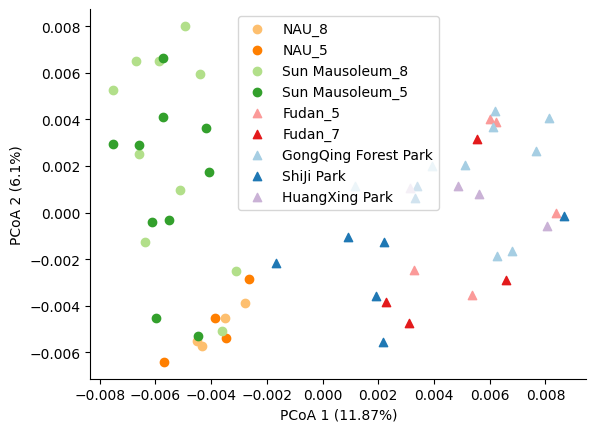

In [16]:
fig, ax = plt.subplots()
ax.scatter(pc1_cpsnj1, pc2_cpsnj1,c='#fdbf6f', label='NAU_8')
ax.scatter(pc1_snj1, pc2_snj1,c='#ff7f00', label='NAU_5')
ax.scatter(pc1_cpsnj2, pc2_cpsnj2,c='#b2df8a',label='Sun Mausoleum_8')
ax.scatter(pc1_snj2, pc2_snj2,c='#33a02c', label='Sun Mausoleum_5')
ax.scatter(pc1_fd5, pc2_fd5,c='#fb9a99',marker='^', label='Fudan_5')
ax.scatter(pc1_fd7, pc2_fd7,c='#e31a1c',marker='^', label='Fudan_7')
ax.scatter(pc1_gq, pc2_gq,c='#a6cee3',marker='^', label='GongQing Forest Park')
ax.scatter(pc1_sj, pc2_sj,c='#1f78b4',marker='^', label='ShiJi Park')
ax.scatter(pc1_hx, pc2_hx,c='#cab2d6',marker='^', label='HuangXing Park')
plt.legend()
ax.set_xlabel('PCoA 1 (11.87%)')
ax.set_ylabel('PCoA 2 (6.1%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

In [8]:
df = pd.read_csv(r'../pre-calculated_data/abundance_significant_results.tsv',sep='\t')
df

,feature,metadata,value,name,coef,null_hypothesis,stderr,pval_individual,qval_individual,pval_joint,qval_joint,error,model,N,N_not_zero
0,g__20CM.2.65.7,City,ShangHai,CityShangHai,4.257748,0.007583,0.428552,5.758727e-13,1.167409e-08,5.758727e-13,6.719858e-09,NaN,abundance,58,56
1,g__JAJKIV01,City,ShangHai,CityShangHai,-1.741287,0.007583,0.204697,4.565548e-11,1.883055e-07,4.565548e-11,1.083927e-07,NaN,abundance,58,58
2,g__JJ008,City,ShangHai,CityShangHai,-1.456088,0.007583,0.168370,3.162937e-11,1.883055e-07,3.162937e-11,1.083927e-07,NaN,abundance,58,58
3,g__Phenylobacterium,City,ShangHai,CityShangHai,-2.328224,0.007583,0.274720,4.644474e-11,1.883055e-07,4.644474e-11,1.083927e-07,NaN,abundance,58,58
4,g__SHXO01,City,ShangHai,CityShangHai,1.956122,0.007583,0.224287,2.711020e-11,1.883055e-07,2.711020e-11,1.083927e-07,NaN,abundance,58,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,g__WYBA01,City,ShangHai,CityShangHai,NaN,0.000000,NaN,NaN,NaN,7.268156e-05,7.710192e-03,All logistic values are the same,prevalence,58,58
728,g__WYBL01,City,ShangHai,CityShangHai,NaN,0.000000,NaN,NaN,NaN,1.111414e-09,1.441009e-06,All logistic values are the same,prevalence,58,58
729,g__WYBW01,City,ShangHai,CityShangHai,NaN,0.000000,NaN,NaN,NaN,2.836397e-03,9.461412e-02,All logistic values are the same,prevalence,58,58
730,g__Z2.YC6860,City,ShangHai,CityShangHai,NaN,0.000000,NaN,NaN,NaN,3.528718e-04,2.393989e-02,All logistic values are the same,prevalence,58,58


In [16]:
df = df[df['model']=='abundance']
df = df[df['metadata']=='City']
df = df[df['qval_joint']<0.05]
df = df[df['error'].isnull()]
df['log_qval_joint'] = -np.log10(df['qval_joint'] )
df = df.head(15)
df

,feature,metadata,value,name,coef,null_hypothesis,stderr,pval_individual,qval_individual,pval_joint,qval_joint,error,model,N,N_not_zero,log_qval_joint
0,g__20CM.2.65.7,City,ShangHai,CityShangHai,4.257748,0.007583,0.428552,5.758727e-13,1.167409e-08,5.758727e-13,6.719858e-09,NaN,abundance,58,56,8.172640
1,g__JAJKIV01,City,ShangHai,CityShangHai,-1.741287,0.007583,0.204697,4.565548e-11,1.883055e-07,4.565548e-11,1.083927e-07,NaN,abundance,58,58,6.965000
2,g__JJ008,City,ShangHai,CityShangHai,-1.456088,0.007583,0.168370,3.162937e-11,1.883055e-07,3.162937e-11,1.083927e-07,NaN,abundance,58,58,6.965000
3,g__Phenylobacterium,City,ShangHai,CityShangHai,-2.328224,0.007583,0.274720,4.644474e-11,1.883055e-07,4.644474e-11,1.083927e-07,NaN,abundance,58,58,6.965000
4,g__SHXO01,City,ShangHai,CityShangHai,1.956122,0.007583,0.224287,2.711020e-11,1.883055e-07,2.711020e-11,1.083927e-07,NaN,abundance,58,58,6.965000
5,g__Novosphingobium,City,ShangHai,CityShangHai,-2.568842,0.007583,0.309846,8.267120e-11,2.793184e-07,8.267120e-11,1.607817e-07,NaN,abundance,58,58,6.793763
6,g__Sphingomonas,City,ShangHai,CityShangHai,-2.277313,0.007583,0.287181,3.012628e-10,8.724570e-07,3.012628e-10,5.022051e-07,NaN,abundance,58,58,6.299119
7,g__SMYC01,City,ShangHai,CityShangHai,2.207776,0.007583,0.275102,7.798562e-10,1.976156e-06,7.798562e-10,1.137518e-06,NaN,abundance,58,50,5.944042
8,g__WYBL01,City,ShangHai,CityShangHai,1.553653,0.007583,0.202810,1.111414e-09,2.503397e-06,1.111414e-09,1.441009e-06,NaN,abundance,58,58,5.841333
9,g__Variovorax,City,ShangHai,CityShangHai,-2.153419,0.007583,0.281766,1.396384e-09,2.830750e-06,1.396384e-09,1.629441e-06,NaN,abundance,58,54,5.787961


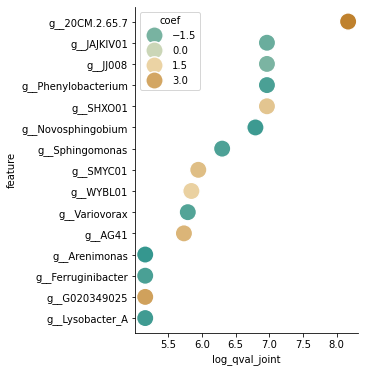

In [18]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", ["#35978f","#f6e8c3","#bf812d" ])
fig, ax = plt.subplots(figsize=(4, 6))
sns.scatterplot(data=df, y='feature', x='log_qval_joint', ax=ax, s=300, marker='o',hue='coef',palette=custom_cmap)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig(r'D:\soil\manuscript\draft\mine\abundance_masslin3_shanghai.svg')